<h3>How was your day!</h3>
From mid-April 2025 - 15th of June 2025, I collected 200 responses to the question "How was your day?".  This project's aim was to act as a public diary to promote self-reflection and mindfulness. 

Github repo: https://git.arts.ac.uk/23008862/Big-Data-2025
Website: https://cci.arts.ac.uk/~elowen/How_was_your_Day/

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk


from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification

from openai import OpenAI


In [25]:
df = pd.read_csv("data/feelings_data.csv")


In [26]:
df

,Submission Time,Age and Data Confirmation,UK region,How was your day?
0,3/13/2025 14:51,"Yes, I am over the age of 18 and I am happy fo...",East Central England,"Amazingly, I got an interview request from a t..."
1,3/13/2025 14:51,"Yes, I am over the age of 18 and I am happy fo...",Northern England,Bad but I loved listening to the bubbling of t...
2,3/13/2025 14:51,"Yes, I am over the age of 18 and I am happy fo...",East Central England,Glad that I can go to University lol
3,3/13/2025 14:52,"Yes, I am over the age of 18 and I am happy fo...",Northern England,Happy that I can (barely) afford rent
4,3/13/2025 14:52,"Yes, I am over the age of 18 and I am happy fo...",Southwest England,Just chilling
...,...,...,...,...
210,6/16/2025 18:01,"Yes, I am over the age of 18 and I am happy fo...",West Central England,wore an outfit i liked and got like three comp...
211,6/16/2025 18:01,"Yes, I am over the age of 18 and I am happy fo...",Southern Scotland,got free food at work!
212,6/16/2025 18:02,"Yes, I am over the age of 18 and I am happy fo...",East Central England,i had energy today and i used it wisely for once
213,6/16/2025 18:02,"Yes, I am over the age of 18 and I am happy fo...",Southeast England,worked on a passion project after my shift :)


In [27]:
feeling_data = df.filter(like="How was your day?")
print(feeling_data)

                                     How was your day?
0    Amazingly, I got an interview request from a t...
1    Bad but I loved listening to the bubbling of t...
2                 Glad that I can go to University lol
3                Happy that I can (barely) afford rent
4                                        Just chilling
..                                                 ...
210  wore an outfit i liked and got like three comp...
211                             got free food at work!
212   i had energy today and i used it wisely for once
213      worked on a passion project after my shift :)
214                                              Good 

[215 rows x 1 columns]


In [28]:
#filtering out harsh language for a family friendly magazine
ignore = ("fuck", "shit", "bitch", "asshole")
#using regex's | (or)
pattern = "|".join(ignore)  

#case=false for case insensitive and na=false to ignore NaN values
filtered_responses = df[df["How was your day?"].str.contains(pattern, case=False, na=False)]

In [29]:
#getting the index of the responses in filtered_responses
df.drop(index=filtered_responses.index, inplace=True)

df

,Submission Time,Age and Data Confirmation,UK region,How was your day?
0,3/13/2025 14:51,"Yes, I am over the age of 18 and I am happy fo...",East Central England,"Amazingly, I got an interview request from a t..."
1,3/13/2025 14:51,"Yes, I am over the age of 18 and I am happy fo...",Northern England,Bad but I loved listening to the bubbling of t...
2,3/13/2025 14:51,"Yes, I am over the age of 18 and I am happy fo...",East Central England,Glad that I can go to University lol
3,3/13/2025 14:52,"Yes, I am over the age of 18 and I am happy fo...",Northern England,Happy that I can (barely) afford rent
4,3/13/2025 14:52,"Yes, I am over the age of 18 and I am happy fo...",Southwest England,Just chilling
...,...,...,...,...
210,6/16/2025 18:01,"Yes, I am over the age of 18 and I am happy fo...",West Central England,wore an outfit i liked and got like three comp...
211,6/16/2025 18:01,"Yes, I am over the age of 18 and I am happy fo...",Southern Scotland,got free food at work!
212,6/16/2025 18:02,"Yes, I am over the age of 18 and I am happy fo...",East Central England,i had energy today and i used it wisely for once
213,6/16/2025 18:02,"Yes, I am over the age of 18 and I am happy fo...",Southeast England,worked on a passion project after my shift :)


In [30]:
#df.drop(df.index[index_filtered_responses], inplace=True)
#df

In [31]:
#Now going to use the similar logic to remove the unconsenting responses
unconsenting_responses = df[df["Age and Data Confirmation"].str.contains("No, I am under the age of 18 or do not consent for the data to be used", case=False, na=False)]

print(unconsenting_responses)
df

Empty DataFrame
Columns: [Submission Time, Age and Data Confirmation, UK region, How was your day?]
Index: []


,Submission Time,Age and Data Confirmation,UK region,How was your day?
0,3/13/2025 14:51,"Yes, I am over the age of 18 and I am happy fo...",East Central England,"Amazingly, I got an interview request from a t..."
1,3/13/2025 14:51,"Yes, I am over the age of 18 and I am happy fo...",Northern England,Bad but I loved listening to the bubbling of t...
2,3/13/2025 14:51,"Yes, I am over the age of 18 and I am happy fo...",East Central England,Glad that I can go to University lol
3,3/13/2025 14:52,"Yes, I am over the age of 18 and I am happy fo...",Northern England,Happy that I can (barely) afford rent
4,3/13/2025 14:52,"Yes, I am over the age of 18 and I am happy fo...",Southwest England,Just chilling
...,...,...,...,...
210,6/16/2025 18:01,"Yes, I am over the age of 18 and I am happy fo...",West Central England,wore an outfit i liked and got like three comp...
211,6/16/2025 18:01,"Yes, I am over the age of 18 and I am happy fo...",Southern Scotland,got free food at work!
212,6/16/2025 18:02,"Yes, I am over the age of 18 and I am happy fo...",East Central England,i had energy today and i used it wisely for once
213,6/16/2025 18:02,"Yes, I am over the age of 18 and I am happy fo...",Southeast England,worked on a passion project after my shift :)


In [32]:
#getting the index of the responses in filtered_responses
unconsenting_index = unconsenting_responses.filter(like = "index")

#converting index from an empty dataframe to a list
index_unconsenting_responses = unconsenting_responses.index.tolist()

df.drop(index=unconsenting_responses.index, inplace=True)

#Below was the first iteration of the df.drop line, unfortunately this doesn't work because after the first filtering the shape changed and now the "filtering through a list of index" way is innacurate
#df.drop(df.index[index_unconsenting_responses], inplace=True)

In [33]:
df

,Submission Time,Age and Data Confirmation,UK region,How was your day?
0,3/13/2025 14:51,"Yes, I am over the age of 18 and I am happy fo...",East Central England,"Amazingly, I got an interview request from a t..."
1,3/13/2025 14:51,"Yes, I am over the age of 18 and I am happy fo...",Northern England,Bad but I loved listening to the bubbling of t...
2,3/13/2025 14:51,"Yes, I am over the age of 18 and I am happy fo...",East Central England,Glad that I can go to University lol
3,3/13/2025 14:52,"Yes, I am over the age of 18 and I am happy fo...",Northern England,Happy that I can (barely) afford rent
4,3/13/2025 14:52,"Yes, I am over the age of 18 and I am happy fo...",Southwest England,Just chilling
...,...,...,...,...
210,6/16/2025 18:01,"Yes, I am over the age of 18 and I am happy fo...",West Central England,wore an outfit i liked and got like three comp...
211,6/16/2025 18:01,"Yes, I am over the age of 18 and I am happy fo...",Southern Scotland,got free food at work!
212,6/16/2025 18:02,"Yes, I am over the age of 18 and I am happy fo...",East Central England,i had energy today and i used it wisely for once
213,6/16/2025 18:02,"Yes, I am over the age of 18 and I am happy fo...",Southeast England,worked on a passion project after my shift :)


In [34]:
#df.to_csv("CleanTestData.csv", sep=',', index=False, encoding='utf-8')

<h2>Emotional Analysis</h2>
I am assigning an emotion to each response so that we can get the response's background colour and to plot the emotions with matplotlib later on.

In [35]:
example = df["How was your day?"][0]
example2 = df["How was your day?"][1]
print(example)
print(example2)

Amazingly, I got an interview request from a tech company yesterday!
Bad but I loved listening to the bubbling of the sopu I made


In [36]:
#tokenizing the response so that the natural laguage model can process the text easier
example_token = nltk.word_tokenize(example)

In [37]:
#loading the model with trained weights (weights = frequency of text token appearances, one token = 1 gram (unigram))
MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

In [38]:
from transformers import pipeline
#classifier = algorithm used to catagorise data, pipeline = designs, develops and deploys the machine learning model
#https://huggingface.co/michellejieli/emotion_text_classifier
classifier = pipeline("sentiment-analysis", model="michellejieli/emotion_text_classifier")

emo_results = []
for i in df["How was your day?"]:
    emo_results.append(classifier(i))


emo_results

Device set to use cpu


model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

c:\Users\Elune\miniconda3\envs\big-data-venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Elune\.cache\huggingface\hub\models--michellejieli--emotion_text_classifier. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


[[{'label': 'surprise', 'score': 0.5414261221885681}],
 [{'label': 'joy', 'score': 0.8075914978981018}],
 [{'label': 'joy', 'score': 0.5095269083976746}],
 [{'label': 'joy', 'score': 0.8674502372741699}],
 [{'label': 'neutral', 'score': 0.9672092795372009}],
 [{'label': 'joy', 'score': 0.9756346344947815}],
 [{'label': 'sadness', 'score': 0.9347484111785889}],
 [{'label': 'anger', 'score': 0.6721158623695374}],
 [{'label': 'neutral', 'score': 0.7389364838600159}],
 [{'label': 'neutral', 'score': 0.9248641133308411}],
 [{'label': 'neutral', 'score': 0.810597836971283}],
 [{'label': 'neutral', 'score': 0.7596238255500793}],
 [{'label': 'neutral', 'score': 0.4661308228969574}],
 [{'label': 'neutral', 'score': 0.7420291304588318}],
 [{'label': 'neutral', 'score': 0.5978516340255737}],
 [{'label': 'joy', 'score': 0.956064760684967}],
 [{'label': 'joy', 'score': 0.884244441986084}],
 [{'label': 'disgust', 'score': 0.4991164207458496}],
 [{'label': 'neutral', 'score': 0.7455329298973083}],
 [

In [39]:
# extracting the list from the top dict
# extract the emotion predictions from the nested list
flat_emo_results = [result[0] for result in emo_results]

# add the original text to each result as a new key
for i, result in enumerate(flat_emo_results):
    result["text"] = df["How was your day?"].iloc[i]

emo_df = pd.DataFrame(flat_emo_results, columns=["text", "label", "score"])
emo_df

,text,label,score
0,"Amazingly, I got an interview request from a t...",surprise,0.541426
1,Bad but I loved listening to the bubbling of t...,joy,0.807591
2,Glad that I can go to University lol,joy,0.509527
3,Happy that I can (barely) afford rent,joy,0.867450
4,Just chilling,neutral,0.967209
...,...,...,...
209,wore an outfit i liked and got like three comp...,neutral,0.722397
210,got free food at work!,joy,0.885863
211,i had energy today and i used it wisely for once,neutral,0.796530
212,worked on a passion project after my shift :),neutral,0.420588


<h3>Emotion to Colour</h3>
I will be calling openAI's API and giving it a prompt that gets the RGB values from the emotion.

In [ ]:
#this was partly modified from the Open Ai's introduction tutorial
client = OpenAI

completion = client.chat.completions.create(
  model="gpt-4.1-nano",
  store=True,
  messages=[
    {"role": "user", "content": "Can you assign a nuanced RGB colour to these emotions: anger, disgust, fear, joy, neutral, sadness, surprise. Please only reply with the RGB colours"}
  ]
)

print(completion.choices[0].message)
#this outputs: ChatCompletionMessage(content='Anger: (178, 34, 34)  \nDisgust: (85, 107, 47)  \nFear: (72, 61, 139)  \nJoy: (255, 215, 0)  \nNeutral: (169, 169, 169)  \nSadness: (70, 130, 180)  \nSurprise: (255, 105, 180)', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None)

ChatCompletionMessage(content='Anger: (139, 0, 0)  \nDisgust: (85, 107, 47)  \nFear: (25, 25, 112)  \nJoy: (255, 215, 0)  \nNeutral: (128, 128, 128)  \nSadness: (70, 130, 180)  \nSurprise: (255, 105, 180)', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None)


In [41]:
#next I will be taking the response and making it into a list
RGB_colours = completion.choices[0].message
type(RGB_colours)

stringified_message = []
[stringified_message.append(i) for i in RGB_colours]

#remving the message parameters
i = 1
while i < len(stringified_message):
    if i < 3:
        stringified_message.pop()
        if i > 3:
            break

stringified_message = dict(stringified_message)

#isolating the "content" value as this is where the colours are
colours = stringified_message["content"]
colours


'Anger: (139, 0, 0)  \nDisgust: (85, 107, 47)  \nFear: (25, 25, 112)  \nJoy: (255, 215, 0)  \nNeutral: (128, 128, 128)  \nSadness: (70, 130, 180)  \nSurprise: (255, 105, 180)'

In [42]:
#Next I will be cleaning the data from colours, right now im thinking about detecting whether there is a capital letter and a ) key , if there is make them into a dictionary?
#^^^ Ended up using regex to do this
import re
test = "Anger: (154, 30, 30)"
#https://developer.mozilla.org/en-US/docs/Web/JavaScript/Guide/Regular_expressions/Cheatsheet
pattern = r"(\w+):\s+\((\d+),\s*(\d+),\s*(\d+)\)"

#matching the regex pattern agains the colours, adding that into a tuple
matches = re.findall(pattern, colours)

#rebuilding the data into a dictionary with int RGB
emotion_dict = {name.lower(): (int(r), int(g), int(b)) for name, r, g, b in matches}
emotion_dict

{'anger': (139, 0, 0),
 'disgust': (85, 107, 47),
 'fear': (25, 25, 112),
 'joy': (255, 215, 0),
 'neutral': (128, 128, 128),
 'sadness': (70, 130, 180),
 'surprise': (255, 105, 180)}

In [43]:
#append the data to the dataframe via the emotion expl (139, 0, 0) will append itself to the anger row
emotion_column = emo_df["label"] 

emo_df["colours"] = emo_df["label"].map(emotion_dict)
emo_df
df["Label"] = emo_df["label"]
df["Colours"] = emo_df["colours"]
df


,Submission Time,Age and Data Confirmation,UK region,How was your day?,Label,Colours
0,3/13/2025 14:51,"Yes, I am over the age of 18 and I am happy fo...",East Central England,"Amazingly, I got an interview request from a t...",surprise,"(255, 105, 180)"
1,3/13/2025 14:51,"Yes, I am over the age of 18 and I am happy fo...",Northern England,Bad but I loved listening to the bubbling of t...,joy,"(255, 215, 0)"
2,3/13/2025 14:51,"Yes, I am over the age of 18 and I am happy fo...",East Central England,Glad that I can go to University lol,joy,"(255, 215, 0)"
3,3/13/2025 14:52,"Yes, I am over the age of 18 and I am happy fo...",Northern England,Happy that I can (barely) afford rent,joy,"(255, 215, 0)"
4,3/13/2025 14:52,"Yes, I am over the age of 18 and I am happy fo...",Southwest England,Just chilling,neutral,"(128, 128, 128)"
...,...,...,...,...,...,...
210,6/16/2025 18:01,"Yes, I am over the age of 18 and I am happy fo...",West Central England,wore an outfit i liked and got like three comp...,joy,"(255, 215, 0)"
211,6/16/2025 18:01,"Yes, I am over the age of 18 and I am happy fo...",Southern Scotland,got free food at work!,neutral,"(128, 128, 128)"
212,6/16/2025 18:02,"Yes, I am over the age of 18 and I am happy fo...",East Central England,i had energy today and i used it wisely for once,neutral,"(128, 128, 128)"
213,6/16/2025 18:02,"Yes, I am over the age of 18 and I am happy fo...",Southeast England,worked on a passion project after my shift :),neutral,"(128, 128, 128)"


<h3>Weather tracker</h3>
I will be using Open Mateo's historical weather API get the temperature data.

In [44]:
#converting the submission time from string to date objects for ease of use!
testTime = df["Submission Time"][1]
type(testTime)
df["Submission Time"] = pd.to_datetime(df["Submission Time"], format="%m/%d/%Y %H:%M")
df

,Submission Time,Age and Data Confirmation,UK region,How was your day?,Label,Colours
0,2025-03-13 14:51:00,"Yes, I am over the age of 18 and I am happy fo...",East Central England,"Amazingly, I got an interview request from a t...",surprise,"(255, 105, 180)"
1,2025-03-13 14:51:00,"Yes, I am over the age of 18 and I am happy fo...",Northern England,Bad but I loved listening to the bubbling of t...,joy,"(255, 215, 0)"
2,2025-03-13 14:51:00,"Yes, I am over the age of 18 and I am happy fo...",East Central England,Glad that I can go to University lol,joy,"(255, 215, 0)"
3,2025-03-13 14:52:00,"Yes, I am over the age of 18 and I am happy fo...",Northern England,Happy that I can (barely) afford rent,joy,"(255, 215, 0)"
4,2025-03-13 14:52:00,"Yes, I am over the age of 18 and I am happy fo...",Southwest England,Just chilling,neutral,"(128, 128, 128)"
...,...,...,...,...,...,...
210,2025-06-16 18:01:00,"Yes, I am over the age of 18 and I am happy fo...",West Central England,wore an outfit i liked and got like three comp...,joy,"(255, 215, 0)"
211,2025-06-16 18:01:00,"Yes, I am over the age of 18 and I am happy fo...",Southern Scotland,got free food at work!,neutral,"(128, 128, 128)"
212,2025-06-16 18:02:00,"Yes, I am over the age of 18 and I am happy fo...",East Central England,i had energy today and i used it wisely for once,neutral,"(128, 128, 128)"
213,2025-06-16 18:02:00,"Yes, I am over the age of 18 and I am happy fo...",Southeast England,worked on a passion project after my shift :),neutral,"(128, 128, 128)"


In [45]:

#The names of the regions according to the table
UK_region_names = ["Southeast England", "South West England", "West Central England", "East Central England", "Northern England", "North Wales", "South Wales", "Northern Scotland", "Southern Scotland", "East Scotland", "West Scotland", "Northern Ireland"]

#How I will be renaming those names
dict_names = ["Southeast_England", "South_West_England", "West_Central_England", "East_Central_England", "Northern_England", "North_Wales", "South_Wales", "Northern_Scotland", "Southern_Scotland", "East_Scotland", "West_Scotland", "Northern_Ireland"]

region_dict_data = {
    #Southeast England (West Wickham)
    "Southeast_England": {
         "SEElon": 51.372362,
         "SEElat": -0.014616,
         },
    #South West England (Tiverton)
    "South_West_England":{
        "SWElon": 50.905664,
        "SWElat": -3.485557,
        },
    #West Central England (Birmingham)
    "West_Central_England": {
        "WCElon": 52.509995,
          "WCElat": -1.865080,
          },
    #East Central England (Downham Market)
    "East_Central_England": {
        "ECElon": 52.606245,
        "ECElat": 0.434704,
        },
    #Northern England (Leeds)
    "Northern_England": {
        "NElon": 53.775789,
        "NElat": -1.572164,
        },
    #North Wales (Llanrwst)
    "North_Wales": {
        "NWlon": 53.138137,
        "NWlat": -3.796187,
        },
    #South Wales (Ystalyfera)
    "South_Wales": {
        "SWlon": 51.758176,
        "SWlat": -3.790636,
        },
    #Northern Scotland(Dufftown)
    "Northern_Scotland": {
        "NSlon": 57.435937,
        "NSlat": -3.127963,
          },
    #Southern Scotland(Beattock)
    "Southern_Scotland": {
        "SSlon": 55.312639,
        "SSlat": -3.454602,
        },
    #East Scotland (Edinburgh)
    "East_Scotland": {
        "ESlon": 55.925822,
        "ESlat": -3.078885,
        },
    #West Scotland (Beith)
    "West_Scotland": {
        "WSlon": 55.749906,
        "WSlat": -4.628348,
        },
    #Northern Ireland (Cookstown)
    "Northern_Ireland": {
        "NIlon": 54.633015,
        "NIlat": -6.741270,
        },
}

dict_codes_lat = [
    "SEElat", "SWElat",  "WCElat",   "ECElat",  "NElat",   "NWlat",   "SWlat",    "NSlat",    "SSlat", "ESlat",    "WSlat",    "NIlat"     
]

dict_codes_lon = [
    "SEElon", "SWElon", "WCElon", "ECElon", "NElon", "NWlon", "SWlon", "NSlon", "SSlon", "ESlon","WSlon","NIlon"
]


In [48]:
#Based off of https://open-meteo.com/en/docs?past_days=61&latitude=-0.014&longitude=51.37&timezone=GMT&forecast_days=16&daily=temperature_2m_mean&hourly=&time_mode=time_interval&start_date=2025-04-20&end_date=2025-06-14
#https://open-meteo.com/

import openmeteo_requests
import requests_cache
from retry_requests import retry

#setting up the API session
cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

url = "https://api.open-meteo.com/v1/forecast"

#create an empty list to hold DataFrames for each region
region_list = [] 
for i in range(len(dict_names)):
    dict_key = dict_names[i]
    lat_key = dict_codes_lat[i]
    lon_key = dict_codes_lon[i]

    #get inner dictionary for this region
    region_info = region_dict_data.get(dict_key)

    lat = region_info.get(lat_key)
    lon = region_info.get(lon_key)

    if lat is None or lon is None:
        continue
    
    #API's parameters
    params = {
        "latitude": lat,
        "longitude": lon,
        "daily": "temperature_2m_mean",
        "timezone": "GMT",
        "start_date": "2025-08-20",
        "end_date": "2025-10-14"
    }

    #getting the response
    responses = openmeteo.weather_api(url, params=params)
    response = responses[0]
    

    #processing the response to extarct the daily temperatures
    daily = response.Daily()
    temp_values = daily.Variables(0).ValuesAsNumpy()
    dates = pd.date_range(
        start=pd.to_datetime(daily.Time(), unit="s", utc=True),
        end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=daily.Interval()),
        inclusive="left",
    )

    #creating a temporary dataframe to hold this
    temp_df = pd.DataFrame({
        "Submission Time": dates,
        "Temperature": temp_values,
        "UK region": dict_key
    })
    region_list.append(temp_df) 
    region_dfs = pd.concat(region_list)

#replacing the underscores so that ["UK Region"]'s in region_dfs and df match
region_dfs["UK region"] = region_dfs["UK region"].str.replace("_"," ")
#region_dfs

#print(df[df["UK region"] == "Southeast England"]["Submission Time"].unique())
#print(region_dfs[region_dfs["UK region"] == "Southeast England"]["Submission Time"].unique())

#making extra sure we've stripped it as much as we can and the data is formatted as the pandas dates
df["UK region"] = df["UK region"].str.strip()
region_dfs["UK region"] = region_dfs["UK region"].str.strip()
df["Submission Time"] = pd.to_datetime(df["Submission Time"]).dt.date
region_dfs["Submission Time"] = pd.to_datetime(region_dfs["Submission Time"]).dt.date

OpenMeteoRequestsError: {'reason': "Parameter 'end_date' is out of allowed range from 2025-06-22 to 2025-10-08", 'error': True}

In [ ]:
#Now that i have the weather information, I will be identifying each row's region and date, finding it region_dfs and returning the temperature
#testTime = df["Submission Time"]
#if df["Submission Time"][1] == pd.Timestamp('2025-03-15 14:51:00'):
#    print("yes")
#else:
#    print("no")
#Outputs: yes

df["Submission Time"] = pd.to_datetime(df["Submission Time"]).dt.date
region_dfs["Submission Time"] = pd.to_datetime(region_dfs["Submission Time"]).dt.date

#merging the temperature based on the UK region and Submission Time
df = df.merge(
    region_dfs[["UK region", "Submission Time", "Temperature"]],
    on=["UK region", "Submission Time"],
    how="left"
)


In [ ]:
#Filling any NA's with the average temp
df.fillna("27.931246", axis=1, inplace=True)
df

,Submission Time,Age and Data Confirmation,UK region,How was your day?,Label,Colours,Temperature
0,2025-04-21,"Yes, I am over the age of 18 and I am happy fo...",East Central England,I got an interview request from a tech company...,joy,"(255, 215, 0)",28.945833
1,2025-04-21,"Yes, I am over the age of 18 and I am happy fo...",Northern England,The way that soup bubbles in a pot,neutral,"(128, 128, 128)",28.652084
2,2025-04-21,"Yes, I am over the age of 18 and I am happy fo...",East Central England,That I can go to university,neutral,"(128, 128, 128)",28.945833
3,2025-04-21,"Yes, I am over the age of 18 and I am happy fo...",Northern England,I can (barely) afford to live in London!,joy,"(255, 215, 0)",28.652084
4,2025-04-21,"Yes, I am over the age of 18 and I am happy fo...",Southwest England,Summer’s coming!,joy,"(255, 215, 0)",27.931246
...,...,...,...,...,...,...,...
196,2025-06-05,"Yes, I am over the age of 18 and I am happy fo...",Northern England,had a good sandwich…,neutral,"(128, 128, 128)",28.081251
197,2025-06-01,"Yes, I am over the age of 18 and I am happy fo...",Northern Scotland,lowkey felt like everyone hated me even though...,sadness,"(0, 0, 139)",28.322916
198,2025-06-02,"Yes, I am over the age of 18 and I am happy fo...",Northern Scotland,survived off caffeine and stubbornness,joy,"(255, 215, 0)",27.970827
199,2025-06-14,"Yes, I am over the age of 18 and I am happy fo...",Southeast England,emotionally not built for capitalism rn,27.931246,27.931246,27.595839


<h3>Topic Identification</h3>
Next I wil use topic identification to find common topics throughout responses. I have chosen BERTopic for this instead of Top2Vec since I'm using a smaller data size.

In [ ]:
from bertopic import BERTopic
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
#Bertopic = https://maartengr.github.io/BERTopic/index.html

stop_words = set(stopwords.words('english'))
#these stopwords are especially common, with a high enough frequency to make their own topic so I had to filter the noise
stop_words.update({"today", "day", "okay", "im", "like", "got", "just", "really"})  
#an idea gotten from my unit tutor Marysia's example, keeping in stopwords uch as no and not as they can change the sentences context
stop_words.difference_update({'no', 'not'})

#lemmetizer = grouping together modified words so they can be analysed as a single item
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    #removing punctuation
    text = re.sub(r"[^\w\s]", "", text.lower()) 
    tokens = nltk.word_tokenize(text)
    #if the word is not in stop_words, pass it through the lemmatizer
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    #return it as one full string
    return " ".join(tokens)

#dropping short responses as these would clog the topic tables
responses = df["How was your day?"].dropna().astype(str)
responses = responses[responses.str.len() > 10] 

filtered_df = df[df["How was your day?"].notna() & (df["How was your day?"] != "")]
filtered_docs = filtered_df["How was your day?"].tolist()

cleaned_responses = [clean_text(r) for r in responses]

In [ ]:
from sentence_transformers import SentenceTransformer
#the model we will be using found here: https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

topic_model = BERTopic(embedding_model=embedding_model)

topics, probs = topic_model.fit_transform(cleaned_responses)

#merging repetitive topics
topic_model.reduce_topics(cleaned_responses, nr_topics="auto")



In [ ]:
#topic = topics that have been idenitifed, count = the number of responses that fall into the topic
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,63,-1_good_friend_made_saw,"[good, friend, made, saw, sun, felt, life, new...","[good since talk friend, pretty good actually ..."
1,0,60,0_work_kind_woke_stayed,"[work, kind, woke, stayed, productive, get, ti...",[went get greggs roommate shopping lidl focusi...
2,1,25,1_felt_something_emotional_lowkey,"[felt, something, emotional, lowkey, room, kno...",[random kid waved street made weirdly emotiona...
3,2,22,2_ive_went_walk_saw,"[ive, went, walk, saw, enjoyed, caught, dance,...","[compliment outta nowhere ive riding high, fin..."
4,3,11,3_toast_excited_making_burnt,"[toast, excited, making, burnt, eat, new, unde...",[bloody shambolic pub undercooked steak overco...


In [ ]:
topic_model.get_topic(1)

[('felt', 0.13064905801520282),
 ('something', 0.1065885617895982),
 ('emotional', 0.0948335767945912),
 ('lowkey', 0.0948335767945912),
 ('room', 0.0948335767945912),
 ('know', 0.08862980238907334),
 ('someone', 0.07666045013016781),
 ('not', 0.071345179664704),
 ('cleaned', 0.06907741367768551),
 ('dumb', 0.06907741367768551)]

In [ ]:
#topic_model.get_representative_docs(1)

custom_labels = {
    -1: "Miscellaneous / Outliers",
    0: "Routine & Tasks",
    1: "Confession & Vulnerability",
    2: "Overwhelm & Anxiety",
    3: "Nature & Mood Boost"
}

topic_model.set_topic_labels(custom_labels)

In [ ]:
topics, probs = topic_model.fit_transform(filtered_docs)
filtered_df["Topic"] = topics

#df["Topic"] = -1 
df.loc[filtered_df.index, "Topic"] = filtered_df["Topic"]

In [ ]:
topic_info = topic_model.get_topic_info()
#mapping the custom labels to the topic index
df["Topic Name"] = df["Topic"].map(custom_labels)
df

NameError: name 'topic_model' is not defined

<h3> Visualisation </h3>

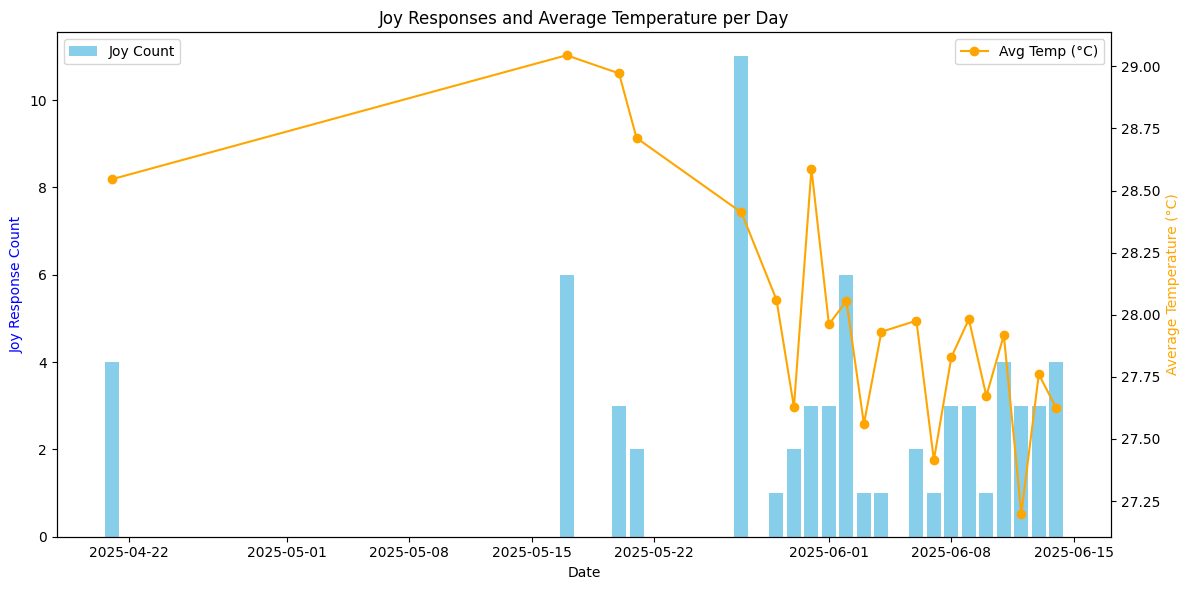

In [ ]:
#getting all the reponses that were labeled "joy"
joy_responses = df[df["Label"].str.contains('joy')]
joy_responses.sort_values(by='Submission Time', ascending=False)

#making EXTRA sure that the submission time is a pandas date type
joy_responses["Submission Time"] = pd.to_datetime(joy_responses["Submission Time"])

#convert temperature to numbers
joy_responses["Temperature"] = pd.to_numeric(joy_responses["Temperature"], errors="coerce")

#getting the joy responses count by the date
daily_counts = joy_responses.groupby("Submission Time").size()

# group by date to get:
# - number of responses
# - mean temperature
grouped = joy_responses.groupby(joy_responses["Submission Time"].dt.date).agg({
    "Temperature": "mean",
    #using any column to count entries per day
    "Label": "count"  
}).rename(columns={"Label": "Joy Count"})


fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart: Joy response count
ax1.bar(grouped.index, grouped["Joy Count"], color="skyblue", label="Joy Count")
ax1.set_ylabel("Joy Response Count", color="blue")
ax1.set_xlabel("Date")

# Line chart: Average temperature on second y-axis
ax2 = ax1.twinx()
ax2.plot(grouped.index, grouped["Temperature"], color="orange", marker='o', label="Avg Temp (°C)")
ax2.set_ylabel("Average Temperature (°C)", color="orange")

# Legends and title
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.title("Joy Responses and Average Temperature per Day")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()